<a href="https://colab.research.google.com/github/Nissan09/PROFESSIONALISM-IN-REAL-TIME-MACHINE-LEARNING-SYSTEM-DESIGN/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from joblib import Parallel, delayed

In [ ]:
#Load the wildfire dataset
file_path = "/content/drive/MyDrive/Dataset_FireWatch_Brazil_Q1_2024.csv"
df = pd.read_csv(file_path)
df.head()

,data,municipio,estado,bioma,avg_numero_dias_sem_chuva,avg_precipitacao,avg_risco_fogo,avg_frp
0,2024-01-01,VALE DO ANARI,RONDÔNIA,Amazônia,0.0,1698.00,0.0,13.00
1,2024-01-01,SÃO GABRIEL DA CACHOEIRA,AMAZONAS,Amazônia,0.2,206.80,0.0,81.40
2,2024-01-01,MANAQUIRI,AMAZONAS,Amazônia,0.0,60.00,0.0,27.00
3,2024-01-01,JUTAÍ,AMAZONAS,Amazônia,2.0,776.00,0.0,211.00
4,2024-01-01,AUTAZES,AMAZONAS,Amazônia,0.0,2.22,0.0,97.67


In [ ]:
#Explore the dataset
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing values:\n", df.isnull().sum())
df.describe()

Shape: (43753, 8)
Columns: ['data', 'municipio', 'estado', 'bioma', 'avg_numero_dias_sem_chuva', 'avg_precipitacao', 'avg_risco_fogo', 'avg_frp']
Missing values:
 data                         0
municipio                    0
estado                       0
bioma                        1
avg_numero_dias_sem_chuva    0
avg_precipitacao             0
avg_risco_fogo               0
avg_frp                      0
dtype: int64


,avg_numero_dias_sem_chuva,avg_precipitacao,avg_risco_fogo,avg_frp
count,43753.000000,43753.000000,43753.000000,43753.000000
mean,3.135743,312.024698,28.830393,122.263815
std,3.634635,778.323011,36.169648,198.683023
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,37.000000
50%,2.000000,10.000000,8.000000,66.000000
75%,4.330000,226.000000,54.000000,113.000000
max,35.000000,23090.000000,100.000000,5390.330000


In [ ]:
#Clean the data
df.dropna(inplace=True)
print("After dropna:", df.shape)

After dropna: (43752, 8)


In [ ]:
#Encode categorical columns
label_cols = ['municipio', 'estado', 'bioma']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
#Prepare features and target
X = df.drop(columns=['avg_frp', 'data'])
y = (df['avg_frp'] > df['avg_frp'].median()).astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
#Train baseline Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
start = time.time()
model.fit(X_train, y_train)
print("Random Forest training time:", round(time.time() - start, 2), "seconds")


Random Forest training time: 7.23 seconds


In [ ]:
#Evaluate the Random Forest model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5937833307938443
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.62      0.61      6617
           1       0.59      0.57      0.58      6509

    accuracy                           0.59     13126
   macro avg       0.59      0.59      0.59     13126
weighted avg       0.59      0.59      0.59     13126



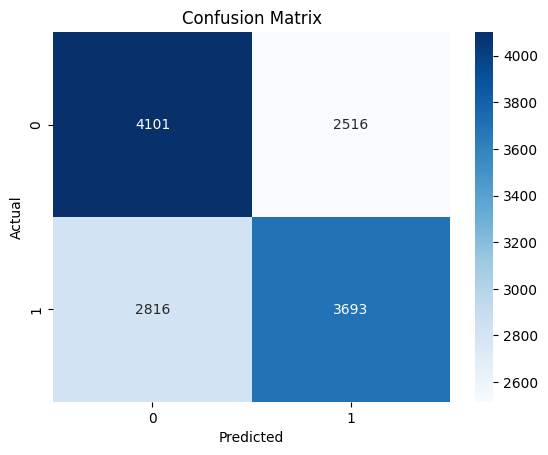

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
#Parallel Training with joblib
def train_rf(n):
    model = RandomForestClassifier(n_estimators=n, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    return model
    start = time.time()
models_parallel = Parallel(n_jobs=2)(delayed(train_rf)(100) for _ in range(2))
print(" Parallel training time:", round(time.time() - start, 2), "seconds")

 Parallel training time: 4805.28 seconds


In [ ]:
#Evaluate Parallel Model
y_pred_parallel = models_parallel[0].predict(X_test)
print("Parallel Model Accuracy:", accuracy_score(y_test, y_pred_parallel))
print("Classification Report:\n", classification_report(y_test, y_pred_parallel))


Parallel Model Accuracy: 0.5937833307938443
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.62      0.61      6617
           1       0.59      0.57      0.58      6509

    accuracy                           0.59     13126
   macro avg       0.59      0.59      0.59     13126
weighted avg       0.59      0.59      0.59     13126



In [ ]:
#XGBoost with CPU fallback
!pip install xgboost --quiet
import xgboost as xgb

# Use CPU fallback instead of GPU due to Colab environment constraints
xgb_model = xgb.XGBClassifier(tree_method='hist', device='cpu', eval_metric='logloss')

start = time.time()
xgb_model.fit(X_train, y_train)
print("XGBoost training time:", round(time.time() - start, 2), "seconds")

XGBoost training time: 2.71 seconds


In [ ]:
#Evaluate XGBoost Model
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.616791101630352
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.67      0.64      6617
           1       0.63      0.56      0.59      6509

    accuracy                           0.62     13126
   macro avg       0.62      0.62      0.62     13126
weighted avg       0.62      0.62      0.62     13126



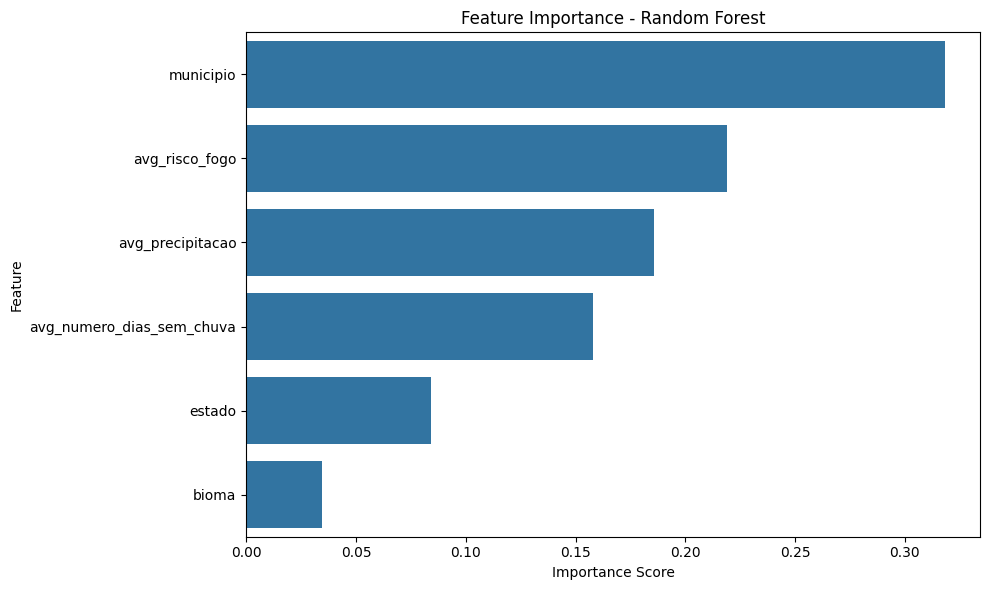

In [ ]:
#Feature Importance Plot
importances = model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df.sort_values(by='importance', ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='importance', y='feature')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()